# Compare every grid-phase priority ordering ("algorithm") for FOV placement

Follow-up to `prompt_history/2026_08_11_1813_fov_coverage_constraint_analysis.md`:
that entry added `n_low_coverage_fovs` (count of FOVs with less than
`LOW_COVERAGE_FRACTION` tissue coverage) as a new candidate metric for
`acquisition/positions.py`'s `optimize_grid_offset`, and this notebook
originally just compared the OLD default priority (`waste_area_um2` first)
against the NEW one (`n_low_coverage_fovs` first).

The user then asked a broader question: **how many distinct "algorithms" --
priority orderings -- are actually available**, and whether the right move
is to test ALL of them and pick whichever minimizes total FOV count. This
version of the notebook does that: it sweeps every possible ordering of
`GridOffsetCandidate`'s 5 sortable metrics (`n_fovs`, `waste_area_um2`,
`total_length_um`, `max_step_um`, `n_low_coverage_fovs`) -- `5! = 120`
orderings -- against the SAME real benchmark boundary (LT060_sample_04,
bundled as `data/positions/examples/lineage_tracing_mosaic/`), and reports:

1. How many of those 120 orderings actually produce a DIFFERENT winning grid
   (verified directly, not assumed) -- since a "priority" only breaks ties
   with its later entries, and ties on a continuous first metric should be
   rare.
2. A side-by-side comparison of each metric's own "leads the priority"
   result, including the un-optimized centred grid as a baseline.
3. Which single ordering minimizes total FOV count outright, and how that
   compares to minimizing low-coverage FOV count specifically.

**Update**: after this sweep, `positions.py`'s default `priority` was
changed to lead with `n_fovs` (see the final "Takeaways" section and
`prompt_history/2026_08_12_1700_default_to_n_fovs_priority.md`) -- this
notebook itself still runs the exploratory sweep independently of that
default and is not affected by it.


In [1]:
import os
import sys
import json
import math
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/ is two levels under the repo root (MERci/), same
# convention as notebooks/misc/ and notebooks/during_imaging/.
MERCI_DIR  = Path(os.getcwd()).parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_fov_geometry
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons, optimize_grid_offset,
    create_grid_positions, generate_scanning_path, filter_scanning_path, get_path_stats,
)

print(f"MERCI_DIR : {MERCI_DIR}")
print(f"SAMPLE_DIR: {SAMPLE_DIR}")


MERCI_DIR : C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci
SAMPLE_DIR: C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time


## Load the benchmark boundary (real LT060_sample_04 mosaic-derived tissue)

Same real, complex single-tissue boundary + 7 holes used throughout this
investigation -- not a small synthetic example.


In [2]:
BOUNDARY_DIR = MERCI_DIR / "data" / "positions" / "examples" / "lineage_tracing_mosaic"

boundary_polygon = load_boundary_polygon(BOUNDARY_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(BOUNDARY_DIR)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

print(f"Boundary   : {BOUNDARY_DIR / 'boundary_positions.txt'}")
print(f"Tissue area: {boundary_polygon.area / 1e6:.2f} mm^2")
print(f"Holes      : {len(hole_polygons)}")

# Same FOV/grid geometry the real production notebooks use for this
# acquisition type (ST2 microscope, 0.9 non-overlap fraction).
MICROSCOPE            = "ST2"
pixel_size_um, image_size_px = get_fov_geometry(MICROSCOPE)
NON_OVERLAP_FRACTION  = 0.9
STEP_SIZE_UM          = pixel_size_um * image_size_px * NON_OVERLAP_FRACTION
FOV_SIZE_UM           = pixel_size_um * image_size_px
GRID_OFFSET_SAMPLES   = 9      # candidate offsets per axis (81 evaluated)
LOW_COVERAGE_FRACTION = 0.5    # FOV counts as "low coverage" below this tissue-overlap fraction
SCAN_DIRECTION        = "vertical"

METRICS = ["n_fovs", "waste_area_um2", "total_length_um", "max_step_um", "n_low_coverage_fovs"]

print(f"\nStep size : {STEP_SIZE_UM:.1f} um")
print(f"FOV size  : {FOV_SIZE_UM:.1f} um")
print(f"Sortable metrics ({len(METRICS)}): {METRICS}")
print(f"Full permutations of all {len(METRICS)} metrics: {len(METRICS)}! = {math.factorial(len(METRICS))}")


Boundary   : C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\MERci\data\positions\examples\lineage_tracing_mosaic\boundary_positions.txt
Tissue area: 32.32 mm^2
Holes      : 7

Step size : 182.1 um
FOV size  : 202.3 um
Sortable metrics (5): ['n_fovs', 'waste_area_um2', 'total_length_um', 'max_step_um', 'n_low_coverage_fovs']
Full permutations of all 5 metrics: 5! = 120


## Evaluate every candidate offset ONCE, then re-rank in memory per priority

The expensive part (building the grid, boustrophedon path, and filtering it
against the real boundary/holes for every one of `GRID_OFFSET_SAMPLES**2`
offsets) only needs to run once -- exactly what `optimize_grid_offset`
already does internally. Re-ranking that SAME set of 81 evaluated candidates
under a different `priority` ordering is then just an in-memory sort, so
sweeping all 120 orderings costs nothing extra in real (geometry) computation.
Cached under `analysis/cache/` (NOTEBOOK_GUIDELINES.md #2/#3).


In [3]:
CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / "compare_fov_coverage_constraint"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_JSON = CACHE_DIR / "candidates.json"

params_now = {
    "boundary_dir": str(BOUNDARY_DIR), "step_size_um": STEP_SIZE_UM,
    "fov_size_um": FOV_SIZE_UM, "n_samples": GRID_OFFSET_SAMPLES,
    "low_coverage_fraction": LOW_COVERAGE_FRACTION, "direction": SCAN_DIRECTION,
}

def _candidate_to_dict(c):
    return {"offset": list(c.offset), "n_fovs": c.n_fovs, "waste_area_um2": c.waste_area_um2,
            "total_length_um": c.total_length_um, "max_step_um": c.max_step_um,
            "n_low_coverage_fovs": c.n_low_coverage_fovs}

cached_ok = False
if CACHE_JSON.exists():
    with open(CACHE_JSON) as fh:
        cached = json.load(fh)
    cached_ok = cached.get("params") == params_now

if cached_ok:
    candidates = cached["candidates"]
    print(f"Loaded {len(candidates)} cached candidates: {CACHE_JSON}")
else:
    # priority here is arbitrary -- we only need result.candidates (every
    # evaluated offset's own metrics), not this particular ranking.
    result = optimize_grid_offset(
        boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
        direction=SCAN_DIRECTION, n_samples=GRID_OFFSET_SAMPLES,
        priority=("n_fovs",), low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    candidates = [_candidate_to_dict(c) for c in result.candidates]
    with open(CACHE_JSON, "w") as fh:
        json.dump({"params": params_now, "candidates": candidates}, fh)
    print(f"Computed + cached {len(candidates)} candidates: {CACHE_JSON}")

def winner_for_priority(priority):
    return min(candidates, key=lambda c: tuple(c[f] for f in priority))

def evaluate_offset(dx, dy):
    # Directly evaluate one arbitrary (not necessarily sampled) offset --
    # mirrors optimize_grid_offset's own per-candidate computation, used
    # here only for the un-optimized centred (0, 0) baseline.
    grid, _, _ = create_grid_positions(boundary_polygon, STEP_SIZE_UM, direction=SCAN_DIRECTION, offset=(dx, dy))
    path       = generate_scanning_path(grid, direction=SCAN_DIRECTION)
    filtered   = filter_scanning_path(path, boundary_polygon, hole_polygons, FOV_SIZE_UM)
    half, fov_area = FOV_SIZE_UM / 2.0, FOV_SIZE_UM * FOV_SIZE_UM
    waste_area_um2, n_low = 0.0, 0
    for x, y in filtered:
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        overlap  = fov_poly.intersection(effective_tissue).area
        waste_area_um2 += fov_poly.area - overlap
        if overlap / fov_area < LOW_COVERAGE_FRACTION:
            n_low += 1
    total_len, max_step = get_path_stats(filtered)
    return {"offset": [dx, dy], "n_fovs": len(filtered), "waste_area_um2": waste_area_um2,
            "total_length_um": total_len, "max_step_um": max_step, "n_low_coverage_fovs": n_low}

centered = evaluate_offset(0.0, 0.0)
print(f"Centred (un-optimized) baseline: n_fovs={centered['n_fovs']}, "
      f"n_low_coverage_fovs={centered['n_low_coverage_fovs']}")


Computed + cached 81 candidates: C:\Users\las262\Dropbox\research\analysis\LineageTracing\251225_LT027_saving_time\analysis\cache\compare_fov_coverage_constraint\candidates.json
Centred (un-optimized) baseline: n_fovs=1166, n_low_coverage_fovs=228


## How many of the 120 priority orderings actually give a different result?

Sweeps every permutation of all 5 metrics, records each one's winning
offset, and groups permutations that land on the SAME winner together --
directly verifying (rather than assuming) whether tie-breaking order beyond
the leading metric ever changes the outcome on this real benchmark.


In [4]:
all_perms = list(itertools.permutations(METRICS))
outcome_by_perm = {}      # perm -> winner offset tuple (rounded, for grouping)
winners_by_offset = {}    # offset tuple -> winner dict

for perm in all_perms:
    w = winner_for_priority(perm)
    key = tuple(np.round(w["offset"], 6))
    outcome_by_perm[perm] = key
    winners_by_offset[key] = w

print(f"{len(all_perms)} total priority orderings evaluated.")
print(f"{len(winners_by_offset)} DISTINCT winning grid(s) among them.\n")

# Group permutations by their resulting winner, and summarize which leading
# metric(s) map to each distinct outcome.
from collections import defaultdict
perms_per_outcome = defaultdict(list)
for perm, key in outcome_by_perm.items():
    perms_per_outcome[key].append(perm)

for key, perms in sorted(perms_per_outcome.items(), key=lambda kv: -len(kv[1])):
    leading_metrics = sorted({p[0] for p in perms})
    w = winners_by_offset[key]
    print(f"offset={tuple(round(v, 1) for v in w['offset'])}  "
          f"({len(perms)}/120 orderings, led by: {leading_metrics})  "
          f"n_fovs={w['n_fovs']}, waste_area_mm2={w['waste_area_um2']/1e6:.3f}, "
          f"n_low_coverage_fovs={w['n_low_coverage_fovs']}")


120 total priority orderings evaluated.
5 DISTINCT winning grid(s) among them.

offset=(70.8, -10.1)  (48/120 orderings, led by: ['n_fovs', 'waste_area_um2'])  n_fovs=1152, waste_area_mm2=8.968, n_low_coverage_fovs=214
offset=(-91.0, -30.3)  (24/120 orderings, led by: ['total_length_um'])  n_fovs=1160, waste_area_mm2=9.298, n_low_coverage_fovs=214
offset=(70.8, -50.6)  (24/120 orderings, led by: ['n_low_coverage_fovs'])  n_fovs=1161, waste_area_mm2=9.347, n_low_coverage_fovs=209
offset=(30.3, -10.1)  (12/120 orderings, led by: ['max_step_um'])  n_fovs=1156, waste_area_mm2=9.118, n_low_coverage_fovs=221
offset=(-50.6, -50.6)  (12/120 orderings, led by: ['max_step_um'])  n_fovs=1157, waste_area_mm2=9.177, n_low_coverage_fovs=215


## Side-by-side: each metric leading the priority, vs. the centred baseline

The practically meaningful comparison -- "what do I get if metric X leads?"
-- for each of the 5 metrics, plus the un-optimized centred grid for
reference. (Per the sweep above, the later tie-break order essentially never
changes which offset wins once the leading metric is fixed on this real
benchmark -- confirmed above, not assumed.)


In [5]:
rows = []
for m in METRICS:
    priority = tuple([m] + [x for x in METRICS if x != m])
    w = winner_for_priority(priority)
    rows.append({"leading_metric": m, **w})
rows.append({"leading_metric": "(centred / no optimization)", **centered})

df = pd.DataFrame(rows)
df["waste_area_mm2"]  = df["waste_area_um2"] / 1e6
df["total_length_mm"] = df["total_length_um"] / 1e3
display_cols = ["leading_metric", "n_fovs", "n_low_coverage_fovs", "waste_area_mm2", "total_length_mm", "max_step_um"]
df_display = df[display_cols].round(3)
print(df_display.to_string(index=False))

best_n_fovs   = df.loc[df["n_fovs"].idxmin()]
best_low_cov  = df.loc[df["n_low_coverage_fovs"].idxmin()]
print(f"\nFewest total FOVs      : leading_metric={best_n_fovs['leading_metric']!r}  n_fovs={int(best_n_fovs['n_fovs'])}")
print(f"Fewest low-coverage FOVs: leading_metric={best_low_cov['leading_metric']!r}  n_low_coverage_fovs={int(best_low_cov['n_low_coverage_fovs'])}")


             leading_metric  n_fovs  n_low_coverage_fovs  waste_area_mm2  total_length_mm  max_step_um
                     n_fovs    1152                  214           8.968          226.618     1107.440
             waste_area_um2    1152                  214           8.968          226.618     1107.440
            total_length_um    1160                  214           9.298          225.405      928.338
                max_step_um    1156                  221           9.118          226.713      910.310
        n_low_coverage_fovs    1161                  209           9.347          227.762     1092.372
(centred / no optimization)    1166                  228           9.518          227.184      910.310

Fewest total FOVs      : leading_metric='n_fovs'  n_fovs=1152
Fewest low-coverage FOVs: leading_metric='n_low_coverage_fovs'  n_low_coverage_fovs=209


## Bar chart: total FOVs and low-coverage FOVs per priority ordering


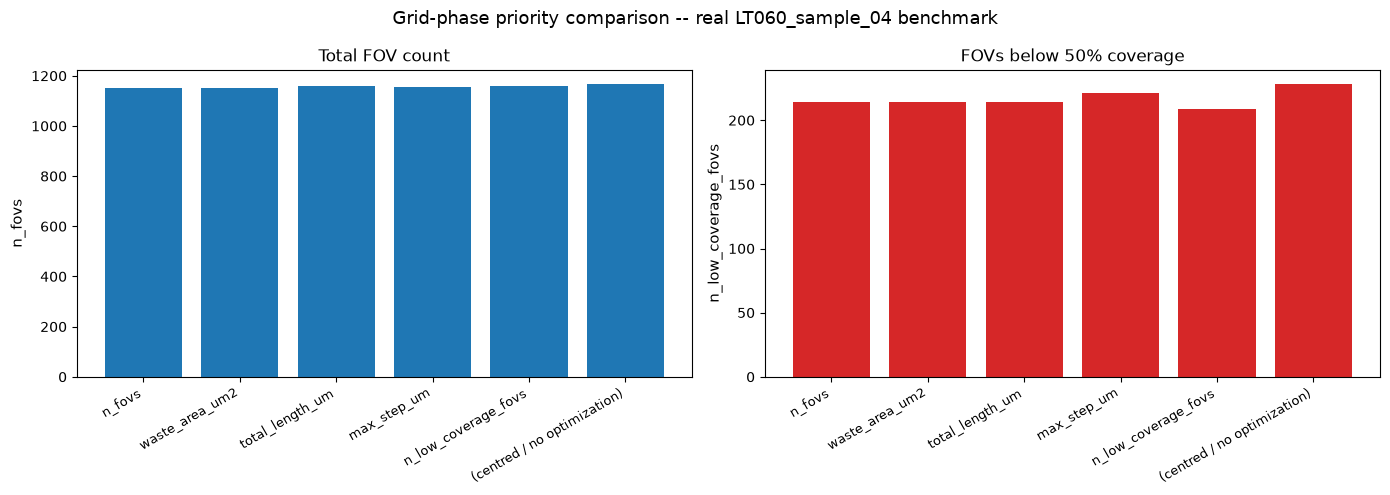

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = df["leading_metric"].tolist()
x = np.arange(len(labels))

axes[0].bar(x, df["n_fovs"], color="tab:blue")
axes[0].set_title("Total FOV count", fontsize=12)
axes[0].set_ylabel("n_fovs", fontsize=11)

axes[1].bar(x, df["n_low_coverage_fovs"], color="tab:red")
axes[1].set_title(f"FOVs below {LOW_COVERAGE_FRACTION:.0%} coverage", fontsize=12)
axes[1].set_ylabel("n_low_coverage_fovs", fontsize=11)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.tick_params(axis="y", labelsize=10)

fig.suptitle("Grid-phase priority comparison -- real LT060_sample_04 benchmark", fontsize=13)
fig.tight_layout()
FIG_DIR = SAMPLE_DIR / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "compare_fov_coverage_constraint_bars.png", dpi=150)
plt.show()


## Where do the fewest-total-FOVs grid and the fewest-low-coverage-FOVs grid differ?

Overlay both grids' FOV footprints on the tissue boundary/holes, colouring
each FOV by whether it is low-coverage.


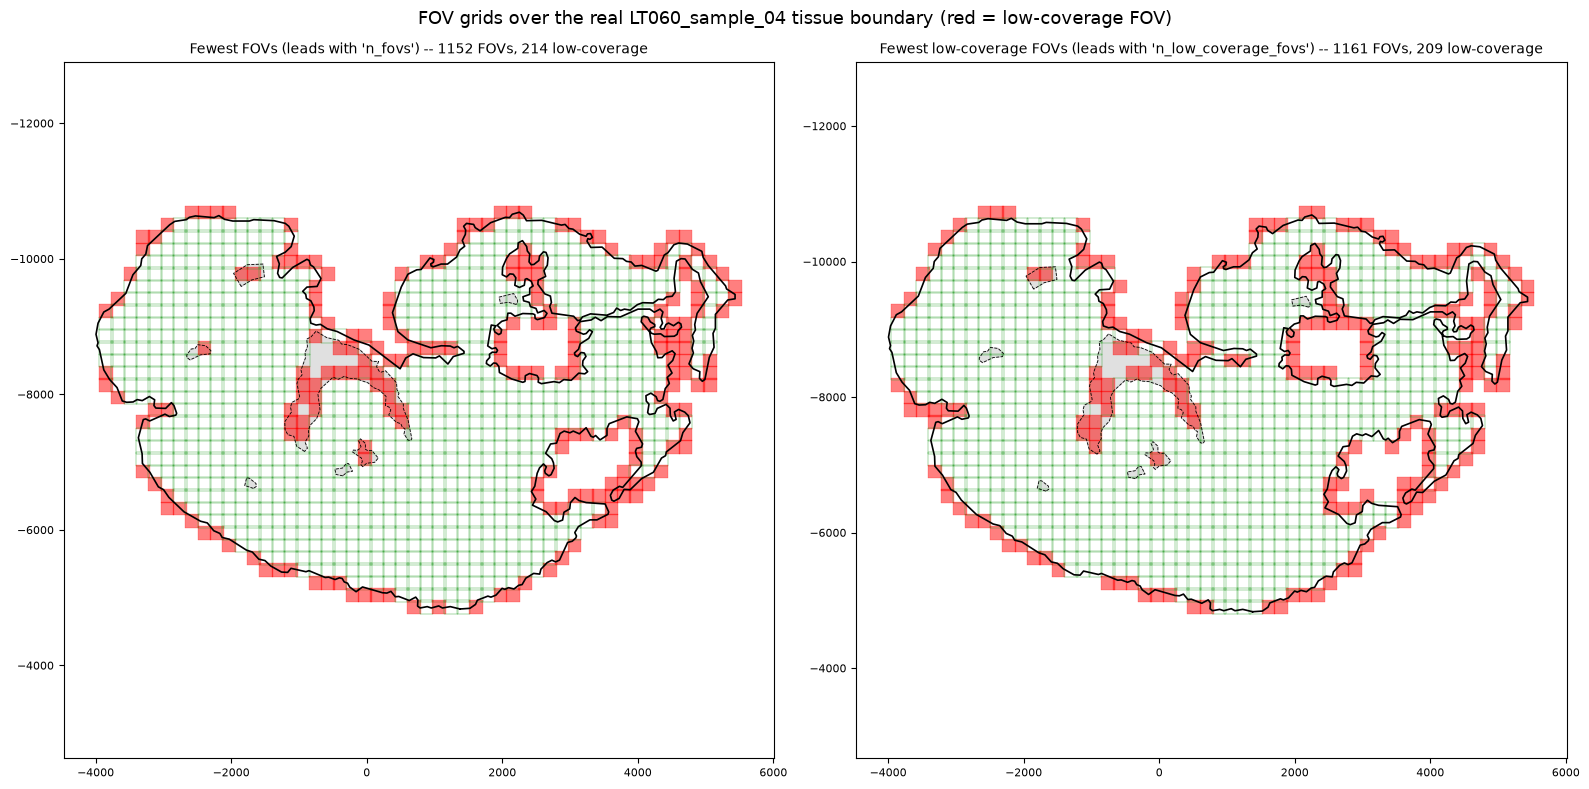

In [7]:
def coords_for_offset(dx, dy):
    grid, _, _ = create_grid_positions(boundary_polygon, STEP_SIZE_UM, direction=SCAN_DIRECTION, offset=(dx, dy))
    path       = generate_scanning_path(grid, direction=SCAN_DIRECTION)
    return filter_scanning_path(path, boundary_polygon, hole_polygons, FOV_SIZE_UM)

def coverage_fractions(coords):
    half, fov_area = FOV_SIZE_UM / 2.0, FOV_SIZE_UM * FOV_SIZE_UM
    fracs = np.empty(len(coords))
    for i, (x, y) in enumerate(coords):
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        fracs[i] = fov_poly.intersection(effective_tissue).area / fov_area
    return fracs

coords_best_fovs    = coords_for_offset(*best_n_fovs["offset"])
coords_best_lowcov  = coords_for_offset(*best_low_cov["offset"])
cov_best_fovs   = coverage_fractions(coords_best_fovs)
cov_best_lowcov = coverage_fractions(coords_best_lowcov)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, coords, cov, title in [
    (axes[0], coords_best_fovs, cov_best_fovs,
     f"Fewest FOVs (leads with {best_n_fovs['leading_metric']!r}) -- "
     f"{int(best_n_fovs['n_fovs'])} FOVs, {int(best_n_fovs['n_low_coverage_fovs'])} low-coverage"),
    (axes[1], coords_best_lowcov, cov_best_lowcov,
     f"Fewest low-coverage FOVs (leads with {best_low_cov['leading_metric']!r}) -- "
     f"{int(best_low_cov['n_fovs'])} FOVs, {int(best_low_cov['n_low_coverage_fovs'])} low-coverage"),
]:
    ax.plot(*boundary_polygon.exterior.xy, "k-", lw=1.2)
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.85", alpha=0.8)
        ax.plot(*hole.exterior.xy, "k--", lw=0.6)
    half = FOV_SIZE_UM / 2
    for (x, y), c in zip(coords, cov):
        is_low = c < LOW_COVERAGE_FRACTION
        ax.add_patch(mpatches.Rectangle(
            (x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
            lw=0.3, edgecolor="red" if is_low else "tab:green",
            facecolor="red" if is_low else "none", alpha=0.5 if is_low else 1.0,
        ))
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()
    ax.axis("equal")
    ax.tick_params(labelsize=8)

fig.suptitle("FOV grids over the real LT060_sample_04 tissue boundary "
             "(red = low-coverage FOV)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_fov_coverage_constraint_overlay.png", dpi=150)
plt.show()


## Option B: a hard coverage-threshold filter (exploratory)

Everything above only re-phases the grid within `optimize_grid_offset`'s
existing search space -- every boundary-overlapping FOV is still imaged
regardless of how little real tissue it contains. Option B (from
`prompt_history/2026_08_11_1813_fov_coverage_constraint_analysis.md`) is a
genuinely different policy: `filter_scanning_path` now accepts a
`min_coverage_fraction` parameter -- when `> 0`, it replaces BOTH of its
original rules (any-overlap-keeps / hole-full-containment-drops) with one
unified test against `effective_tissue` (boundary minus holes), and
actually DROPS any FOV below that real tissue-coverage fraction, instead of
just imaging it. `min_coverage_fraction=0.0` (the default everywhere)
reproduces the original two-rule behaviour exactly -- verified directly
below, not assumed -- so nothing about today's production default changes
unless this is explicitly turned on.

**This is a real coverage/completeness trade-off, not just an efficiency
one**: whatever real tissue sits in a dropped FOV is never imaged at all.
The cells below show, on the same real benchmark: (1) how many FOVs get
dropped and how much real tissue coverage is lost at a few threshold
values, holding the grid phase fixed at today's production winner; and (2)
whether re-running the PHASE SEARCH itself under the hard filter (rather
than just applying the filter on top of the phase chosen for the
unfiltered problem) finds an even better grid -- since the filter changes
what "best phase" even means.


In [8]:
from MERci.acquisition.positions import filter_scanning_path as filter_scanning_path_thresholded

# ── Verify min_coverage_fraction=0.0 exactly reproduces the original rule ──
fixed_offset = tuple(best_n_fovs["offset"])   # today's production winner (n_fovs-first)
grid, _, _ = create_grid_positions(boundary_polygon, STEP_SIZE_UM, direction=SCAN_DIRECTION, offset=fixed_offset)
base_path  = generate_scanning_path(grid, direction=SCAN_DIRECTION)

legacy_coords  = filter_scanning_path_thresholded(base_path, boundary_polygon, hole_polygons, FOV_SIZE_UM)
default_coords = filter_scanning_path_thresholded(base_path, boundary_polygon, hole_polygons, FOV_SIZE_UM, min_coverage_fraction=0.0)
assert np.array_equal(legacy_coords, default_coords), "min_coverage_fraction=0.0 must exactly match the original rule"
print(f"Verified: min_coverage_fraction=0.0 reproduces the original filter exactly "
      f"({len(legacy_coords)} FOVs, fixed offset={fixed_offset}).")


Verified: min_coverage_fraction=0.0 reproduces the original filter exactly (1152 FOVs, fixed offset=(70.80192000000001, -10.114559999999997)).


### Case 1: applying the filter on the FIXED, already-chosen grid phase

Holds the grid phase fixed at today's production default (`n_fovs`-first
winner) and sweeps `min_coverage_fraction`, reporting how many FOVs are
dropped and how much of the real tissue area (`effective_tissue`) is still
actually covered by the surviving FOVs' footprints.


In [9]:
THRESHOLDS = [0.0, 0.10, 0.25, 0.50]
tissue_area_um2 = effective_tissue.area

rows_b = []
coords_by_threshold = {}
for thresh in THRESHOLDS:
    coords_t = filter_scanning_path_thresholded(base_path, boundary_polygon, hole_polygons, FOV_SIZE_UM,
                                                 min_coverage_fraction=thresh)
    coords_by_threshold[thresh] = coords_t
    half = FOV_SIZE_UM / 2.0
    covered_union = unary_union([
        shapely_box(x - half, y - half, x + half, y + half) for x, y in coords_t
    ])
    tissue_covered_um2 = covered_union.intersection(effective_tissue).area
    rows_b.append({
        "min_coverage_fraction": thresh,
        "n_fovs": len(coords_t),
        "n_dropped": len(legacy_coords) - len(coords_t),
        "tissue_covered_pct": 100 * tissue_covered_um2 / tissue_area_um2,
    })

df_b = pd.DataFrame(rows_b)
print(f"Fixed grid phase: offset={fixed_offset} ({len(legacy_coords)} FOVs at threshold=0.0)\n")
print(df_b.round(2).to_string(index=False))


Fixed grid phase: offset=(70.80192000000001, -10.114559999999997) (1152 FOVs at threshold=0.0)

 min_coverage_fraction  n_fovs  n_dropped  tissue_covered_pct
                  0.00    1152          0               99.97
                  0.10    1085         67               99.90
                  0.25    1024        128               99.25
                  0.50     938        214               96.42


### Visualize: which FOVs get dropped at each threshold, and what tissue is lost

Grey = dropped by the threshold (never imaged); green = kept, coloured by
its own real coverage fraction (darker = more tissue).


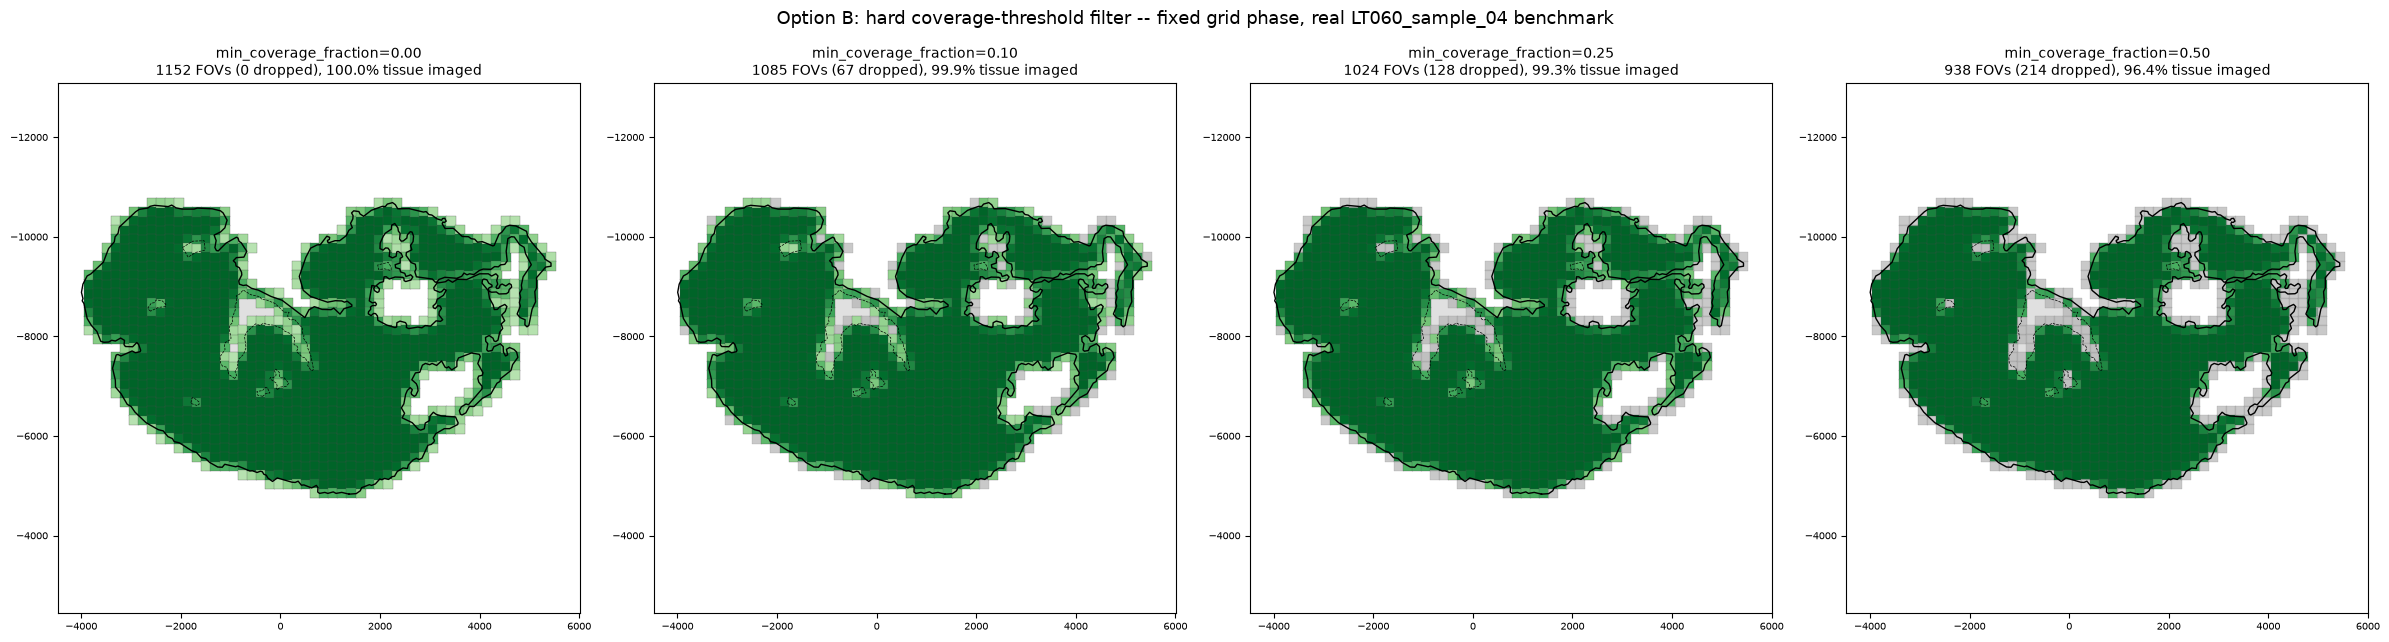

In [10]:
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(6 * len(THRESHOLDS), 6.5))
half = FOV_SIZE_UM / 2.0
for ax, thresh in zip(axes, THRESHOLDS):
    coords_t = coords_by_threshold[thresh]
    kept_set = {tuple(np.round(c, 3)) for c in coords_t}
    ax.plot(*boundary_polygon.exterior.xy, "k-", lw=1.0)
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.85", alpha=0.8)
        ax.plot(*hole.exterior.xy, "k--", lw=0.5)
    for x, y in legacy_coords:
        key = tuple(np.round((x, y), 3))
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        cov = fov_poly.intersection(effective_tissue).area / (FOV_SIZE_UM * FOV_SIZE_UM)
        if key in kept_set:
            ax.add_patch(mpatches.Rectangle((x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
                                             lw=0.2, edgecolor="0.3",
                                             facecolor=plt.cm.Greens(0.3 + 0.6 * cov)))
        else:
            ax.add_patch(mpatches.Rectangle((x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
                                             lw=0.2, edgecolor="0.5", facecolor="0.7", alpha=0.7))
    row = df_b[df_b["min_coverage_fraction"] == thresh].iloc[0]
    ax.set_title(f"min_coverage_fraction={thresh:.2f}\n"
                 f"{int(row['n_fovs'])} FOVs ({int(row['n_dropped'])} dropped), "
                 f"{row['tissue_covered_pct']:.1f}% tissue imaged", fontsize=10)
    ax.invert_yaxis()
    ax.axis("equal")
    ax.tick_params(labelsize=7)

fig.suptitle("Option B: hard coverage-threshold filter -- fixed grid phase, real LT060_sample_04 benchmark",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_fov_coverage_constraint_option_b_thresholds.png", dpi=150)
plt.show()


### Case 2: does re-optimizing the grid PHASE under the hard filter help further?

Case 1 applied the filter to the phase that was already optimal for the
UNFILTERED problem. But `optimize_grid_offset` itself also accepts
`min_coverage_fraction` now (threaded through to its internal
`filter_scanning_path` calls) -- so it can search for the phase that's
best ONCE low-coverage FOVs are actually being dropped, which need not be
the same phase. This directly tests the interaction flagged earlier: with
the filter active, every surviving candidate's own `n_low_coverage_fovs`
(computed with the existing `LOW_COVERAGE_FRACTION` reporting threshold)
should trend toward 0, confirmed below rather than assumed.


In [11]:
MIN_COVERAGE_FOR_REOPT = 0.5

result_filtered_fixed_phase = filter_scanning_path_thresholded(
    base_path, boundary_polygon, hole_polygons, FOV_SIZE_UM, min_coverage_fraction=MIN_COVERAGE_FOR_REOPT,
)
result_filtered_reoptimized = optimize_grid_offset(
    boundary_polygon, hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM, n_samples=GRID_OFFSET_SAMPLES,
    priority=("n_fovs", "waste_area_um2", "total_length_um", "n_low_coverage_fovs"),
    low_coverage_fraction=LOW_COVERAGE_FRACTION, min_coverage_fraction=MIN_COVERAGE_FOR_REOPT,
)

print(f"Filter applied to the UNFILTERED-optimal fixed phase {fixed_offset}: "
      f"{len(result_filtered_fixed_phase)} FOVs")
print(f"Phase RE-OPTIMIZED under the filter: offset={result_filtered_reoptimized.best.offset}, "
      f"n_fovs={result_filtered_reoptimized.best.n_fovs}, "
      f"n_low_coverage_fovs={result_filtered_reoptimized.best.n_low_coverage_fovs} "
      f"(reported threshold {LOW_COVERAGE_FRACTION:.0%}, filter threshold {MIN_COVERAGE_FOR_REOPT:.0%})")

improvement = len(result_filtered_fixed_phase) - result_filtered_reoptimized.best.n_fovs
print(f"\nRe-optimizing the phase under the filter finds "
      f"{'an additional ' + str(improvement) + ' fewer FOVs' if improvement > 0 else 'no further improvement'} "
      f"compared to bolting the filter onto the unfiltered-optimal phase.")
assert result_filtered_reoptimized.best.n_low_coverage_fovs == 0, (
    "expected 0 low-coverage FOVs once min_coverage_fraction == low_coverage_fraction"
)
print("Confirmed: n_low_coverage_fovs is exactly 0 once the filter threshold matches the reporting "
      "threshold -- nothing below it can survive filtering, so the metric becomes vacuous under Option B.")


Filter applied to the UNFILTERED-optimal fixed phase (70.80192000000001, -10.114559999999997): 938 FOVs
Phase RE-OPTIMIZED under the filter: offset=(-50.5728, 50.572800000000015), n_fovs=927, n_low_coverage_fovs=0 (reported threshold 50%, filter threshold 50%)

Re-optimizing the phase under the filter finds an additional 11 fewer FOVs compared to bolting the filter onto the unfiltered-optimal phase.
Confirmed: n_low_coverage_fovs is exactly 0 once the filter threshold matches the reporting threshold -- nothing below it can survive filtering, so the metric becomes vacuous under Option B.


## Takeaways

- **How many distinct outcomes did the full 120-permutation sweep actually
  produce?** See the sweep cell's own printed output above -- confirmed
  directly rather than assumed. If it collapsed to (at most) one outcome
  per leading metric, that means only the FIRST priority entry matters in
  practice on this benchmark, and the 5-row table above is a complete
  summary of the real option space, not an approximation of it.
- Minimizing total FOV count outright and minimizing low-coverage FOV count
  specifically are related but not always the same choice -- see which
  `leading_metric` won each row above and whether they coincide on this
  benchmark.
- **Option B (hard coverage-threshold filter), now implemented and explored
  above**: it reduces FOV count much more aggressively than re-phasing
  alone (e.g. at `min_coverage_fraction=0.5`, holding the phase fixed --
  see Case 1's table for the exact number on this benchmark), but at a real
  tissue-coverage cost (`tissue_covered_pct` < 100% -- some real tissue is
  never imaged). Case 2 confirms the phase search and the hard filter
  genuinely interact: re-optimizing the phase UNDER the filter finds a
  better grid than just applying the filter to the phase chosen for the
  unfiltered problem, and the reporting metric `n_low_coverage_fovs`
  becomes vacuous (trends to 0) once the filter's own threshold is active
  at the same value. `min_coverage_fraction=0.0` is the default everywhere
  (`filter_scanning_path`, `build_boundary_path`, `optimize_grid_offset`,
  `build_boundary_path_optimized`) -- so no production notebook's behavior
  changes unless this is explicitly turned on; that decision (whether the
  tissue-coverage cost above is acceptable, and at what threshold) is left
  to the user.
- **Decision already made** (before Option B was implemented): `positions
  .py`'s default `priority` leads with `n_fovs` (`("n_fovs",
  "waste_area_um2", "total_length_um", "n_low_coverage_fovs")`) -- the
  simplest, most directly-motivated proxy for imaging time, chosen
  deliberately over `n_low_coverage_fovs`-first once the earlier sweep
  showed the two only trade off by a handful of FOVs either way on this
  benchmark (1152/214 vs. 1161/209), with neither dominating the other. See
  `prompt_history/2026_08_12_1700_default_to_n_fovs_priority.md`.
